In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import math

NameError: name 'log' is not defined

In [15]:
os.getcwd()

'C:\\Users\\reyf0\\Dropbox\\Work_Classification\\01-Open_Projects\\Writing_Sample\\Data\\Codes'

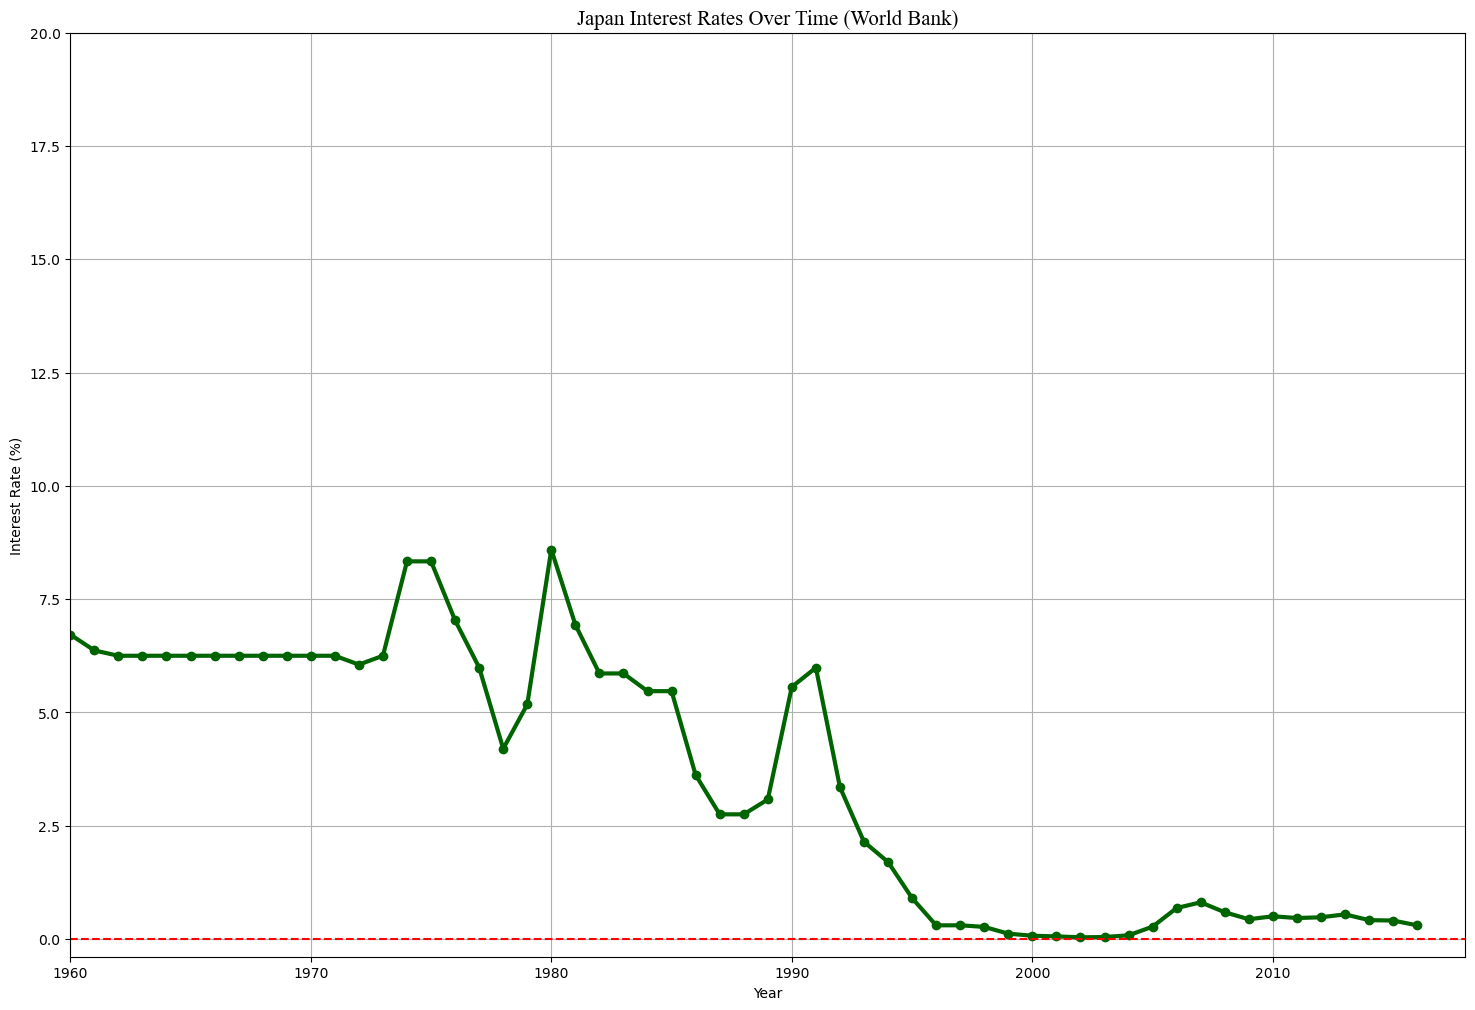

In [307]:
df = pd.read_csv('C:\\Users\\reyf0\\Dropbox\\Work_Classification\\01-Open_Projects\\Writing_Sample\\Data\\Raw_data\\InterestRates.csv', skiprows=4)
japan = df[df['Country Name'].str.strip() == 'Japan'].iloc[0]
year_cols = [col for col in df.columns if col.isdigit()]
years = pd.to_numeric(year_cols)
rates = pd.to_numeric(japan[year_cols].values, errors='coerce')

data = pd.DataFrame({'Year': years, 'Rate': rates}).dropna()

plt.figure(figsize=(18, 12))
plt.plot(data['Year'], data['Rate'], color = "Darkgreen", marker = 'o',lw = 3)
plt.title('Japan Interest Rates Over Time (World Bank)', fontname = "Times New Roman", fontsize = 15)
plt.xlim(left = 1960, right = 2018)
plt.ylim(top = 20)
plt.xlabel('Year'); plt.ylabel('Interest Rate (%)')
plt.grid()
plt.axhline(0, color='r', linestyle='--')
#plt.savefig('C:\\Users\\reyf0\\Dropbox\\Work_Classification\\01-Open_Projects\\Writing_Sample\\Data\\Charts\\Deposit interest rates (WB).png', dpi=600)

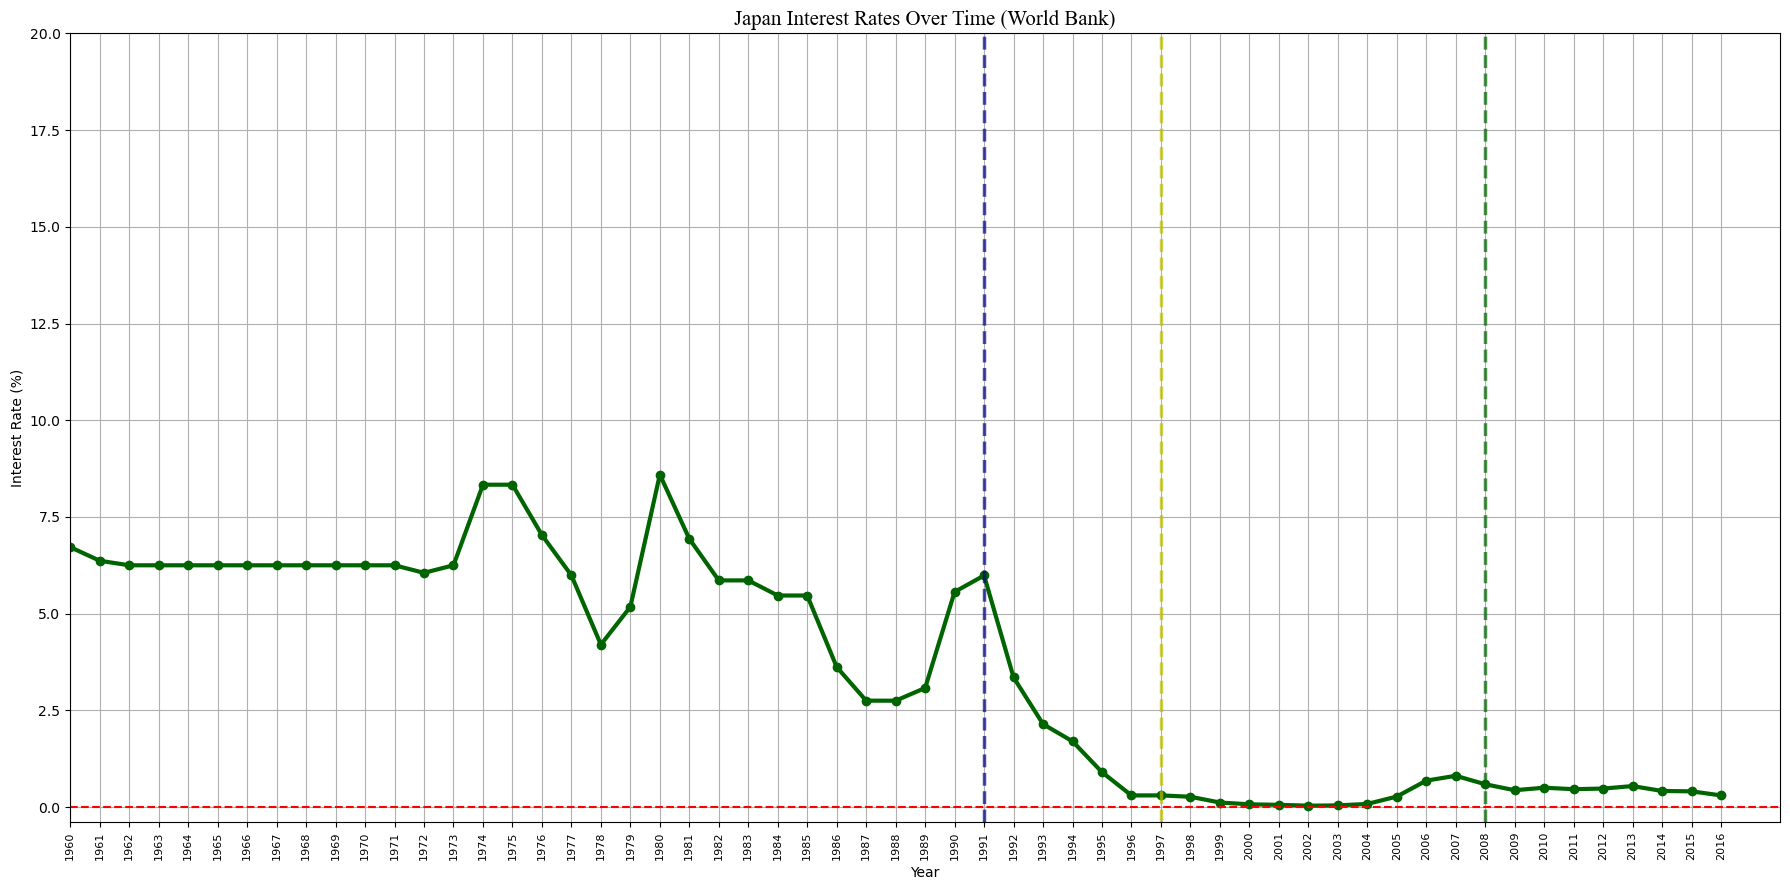

In [309]:
plt.figure(figsize=(18, 9))

plt.plot(
    data['Year'],
    data['Rate'],
    color="Darkgreen",
    marker='o',
    lw=3
)

# Force annual ticks
plt.xticks(
    range(int(data['Year'].min()),
          int(data['Year'].max()) + 1,
          1),
    rotation=90,
    fontsize=8
)

plt.title(
    'Japan Interest Rates Over Time (World Bank)',
    fontname="Times New Roman",
    fontsize=15
)

plt.xlim(left=1960, right=2018)
plt.ylim(top=20)

plt.axvline(1991, linestyle='--', alpha=0.7, lw=2.5, color='Darkblue', label='Asset Bubble Burst')
plt.axvline(1997, linestyle='--', alpha=0.7, lw=2.5, color='y', label='Asian Financial Crisis')
plt.axvline(2008, linestyle='--', alpha=0.7, lw=2.5, color='Darkgreen', label='Global Financial Crisis')
plt.axvline(2020, linestyle='--', alpha=0.7, lw=2.5, color='gray', label='COVID-19 Pandemic')

plt.xlabel('Year')
plt.ylabel('Interest Rate (%)')

plt.grid()
plt.axhline(0, color='r', linestyle='--')

plt.tight_layout()
#plt.savefig('C:\\Users\\reyf0\\Dropbox\\Work_Classification\\01-Open_Projects\\Writing_Sample\\Data\\Charts\\Deposit interest rates (WB).png', dpi=600)

In [35]:

# Load the data
df = pd.read_csv('C:\\Users\\reyf0\\Dropbox\\Work_Classification\\01-Open_Projects\\Writing_Sample\\Data\\Raw_data\\InterestRates.csv', skiprows=4)

# Extract Japan and Global (GLBB row ~271)
japan = df[df['Country Name'].str.strip() == 'Japan'].iloc[0]
global_row = df.iloc[270]  # 0-based index for row 271 (GLBB)

# Get year columns
year_cols = [col for col in df.columns if col.isdigit()]

# Convert to numeric
years = pd.to_numeric(year_cols)
japan_rates = pd.to_numeric(japan[year_cols].values, errors='coerce')
global_rates = pd.to_numeric(global_row[year_cols].values, errors='coerce')

# Create clean DataFrame
data = pd.DataFrame({
    'Year': years,
    'Japan Rate (%)': japan_rates,
    'Global Rate (%)': global_rates
}).dropna(subset=['Japan Rate (%)'])

print("Data summary:")
print(data.head())
print(data.tail())

# Plot with Global comparison ("Globe")
plt.figure(figsize=(14, 7))
plt.plot(data['Year'], data['Japan Rate (%)'], marker='o', linewidth=2.5, label='Japan')
if not data['Global Rate (%)'].isnull().all():
    plt.plot(data['Year'], data['Global Rate (%)'], marker='s', linestyle='--', linewidth=2, label='Global (GLBB)')

plt.title('Japan vs Global Interest Rates (World Bank Data)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Zero Rate Threshold')
plt.legend(fontsize=11)

# Key inflection points
inflections = {1973: 'Oil Shock', 1990: 'Bubble Peak', 2008: 'GFC'}
for y, label in inflections.items():
    if y in data['Year'].values:
        rate = data[data['Year'] == y]['Japan Rate (%)'].values[0]
        plt.axvline(x=y, color='green', linestyle='--', alpha=0.6)
        plt.text(y + 1, rate + 0.5, f'{label}\n({y})', rotation=90, fontsize=10, color='darkgreen')

plt.tight_layout()
plt.show()

# Save for DOCX
#plt.savefig('/home/workdir/attachments/japan_vs_global_interest_rates.png', dpi=300)
#print('Chart saved as japan_vs_global_interest_rates.png')

IndexError: single positional indexer is out-of-bounds

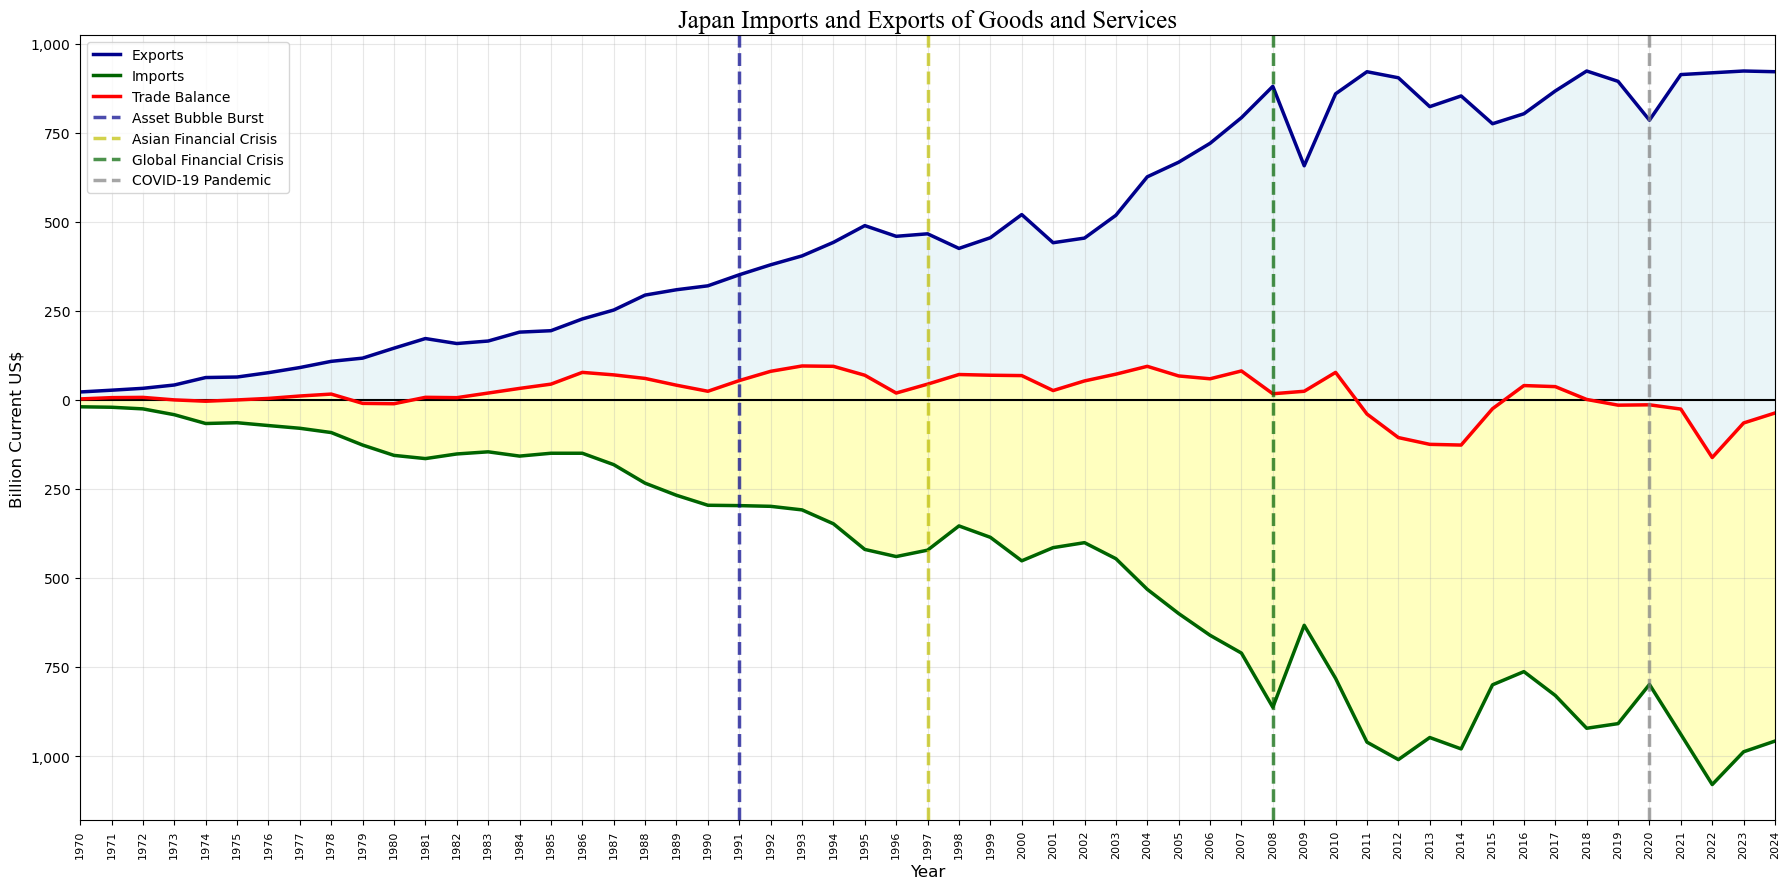

In [310]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ==================================================
# LOAD WORLD BANK FILES
# ==================================================

exports = pd.read_csv(
    r'C:\Users\reyf0\Dropbox\Work_Classification\01-Open_Projects\Writing_Sample\Data\Raw_data\Exports of goods and servises (current USD).csv',
    skiprows=4
)

imports = pd.read_csv(
    r'C:\Users\reyf0\Dropbox\Work_Classification\01-Open_Projects\Writing_Sample\Data\Raw_data\Imports of goods and servises (current USD).csv',
    skiprows=4
)

# ==================================================
# FIND JAPAN ROW
# ==================================================

country_col = exports.columns[0]

exports_japan = exports[exports[country_col] == 'Japan']
imports_japan = imports[imports[country_col] == 'Japan']

# ==================================================
# FIND YEAR COLUMNS AUTOMATICALLY
# ==================================================

year_cols = []

for col in exports.columns:
    col_str = str(col).strip()

    if col_str.isdigit():
        year = int(col_str)

        if 1900 <= year <= 2100:
            year_cols.append(col_str)

# ==================================================
# BUILD CLEAN DATASET
# ==================================================

trade = pd.DataFrame({
    'Year': [int(y) for y in year_cols],
    'Exports': exports_japan[year_cols].iloc[0].astype(float).values,
    'Imports': imports_japan[year_cols].iloc[0].astype(float).values
})

trade = trade.dropna()
trade = trade.sort_values('Year')

# Mirror imports below zero
trade['Imports_Negative'] = -trade['Imports']
trade['Differences'] = trade["Exports"]-trade["Imports"]
# ==================================================
# PLOT
# ==================================================

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(18, 9))

# Exports
ax.plot(
    trade['Year'],
    trade['Exports'],
    linewidth=2.5,
    label='Exports', 
    color = 'Darkblue'
)

# Imports (mirrored below zero)
ax.plot(
    trade['Year'],
    trade['Imports_Negative'],
    linewidth=2.5,
    label='Imports',
    color = "Darkgreen"
)

# Filled areas
ax.fill_between(
    trade['Year'],
    trade["Differences"],
    trade['Exports'],
    alpha=0.25,
    color = "Lightblue"
)

ax.fill_between(
    trade['Year'],
    trade['Differences'],
    trade['Imports_Negative'],
    alpha=0.25,
    color = "yellow"
)

# Zero line
ax.axhline(0, color='black', linewidth=1.5)

ax.plot(trade["Year"], trade["Differences"], lw = 2.5, color = "red", label = "Trade Balance")


ax.set_xlim(left = 1970, right = 2024)

# ==================================================
# INFLECTION POINTS
# ==================================================
plt.axvline(1991, linestyle='--', alpha=0.7, lw=2.5, color='Darkblue', label='Asset Bubble Burst')
plt.axvline(1997, linestyle='--', alpha=0.7, lw=2.5, color='y', label='Asian Financial Crisis')
plt.axvline(2008, linestyle='--', alpha=0.7, lw=2.5, color='Darkgreen', label='Global Financial Crisis')
plt.axvline(2020, linestyle='--', alpha=0.7, lw=2.5, color='gray', label='COVID-19 Pandemic')
# ==================================================
# FORCE EVERY YEAR TO APPEAR
# ==================================================

years = trade['Year'].astype(int)

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=90, fontsize=8)

# ==================================================
# FORMAT Y AXIS
# ==================================================

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{abs(x)/1e9:,.0f}')
)


# ==================================================
# LABELS
# ==================================================

ax.set_title(
    'Japan Imports and Exports of Goods and Services',
    fontsize=18, 
    fontname = "Times New Roman"
)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Billion Current US$', fontsize=12)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()


#plt.savefig('C:\\Users\\reyf0\\Dropbox\\Work_Classification\\01-Open_Projects\\Writing_Sample\\Data\\Charts\\TradeBalance (WB).png', dpi = 600)

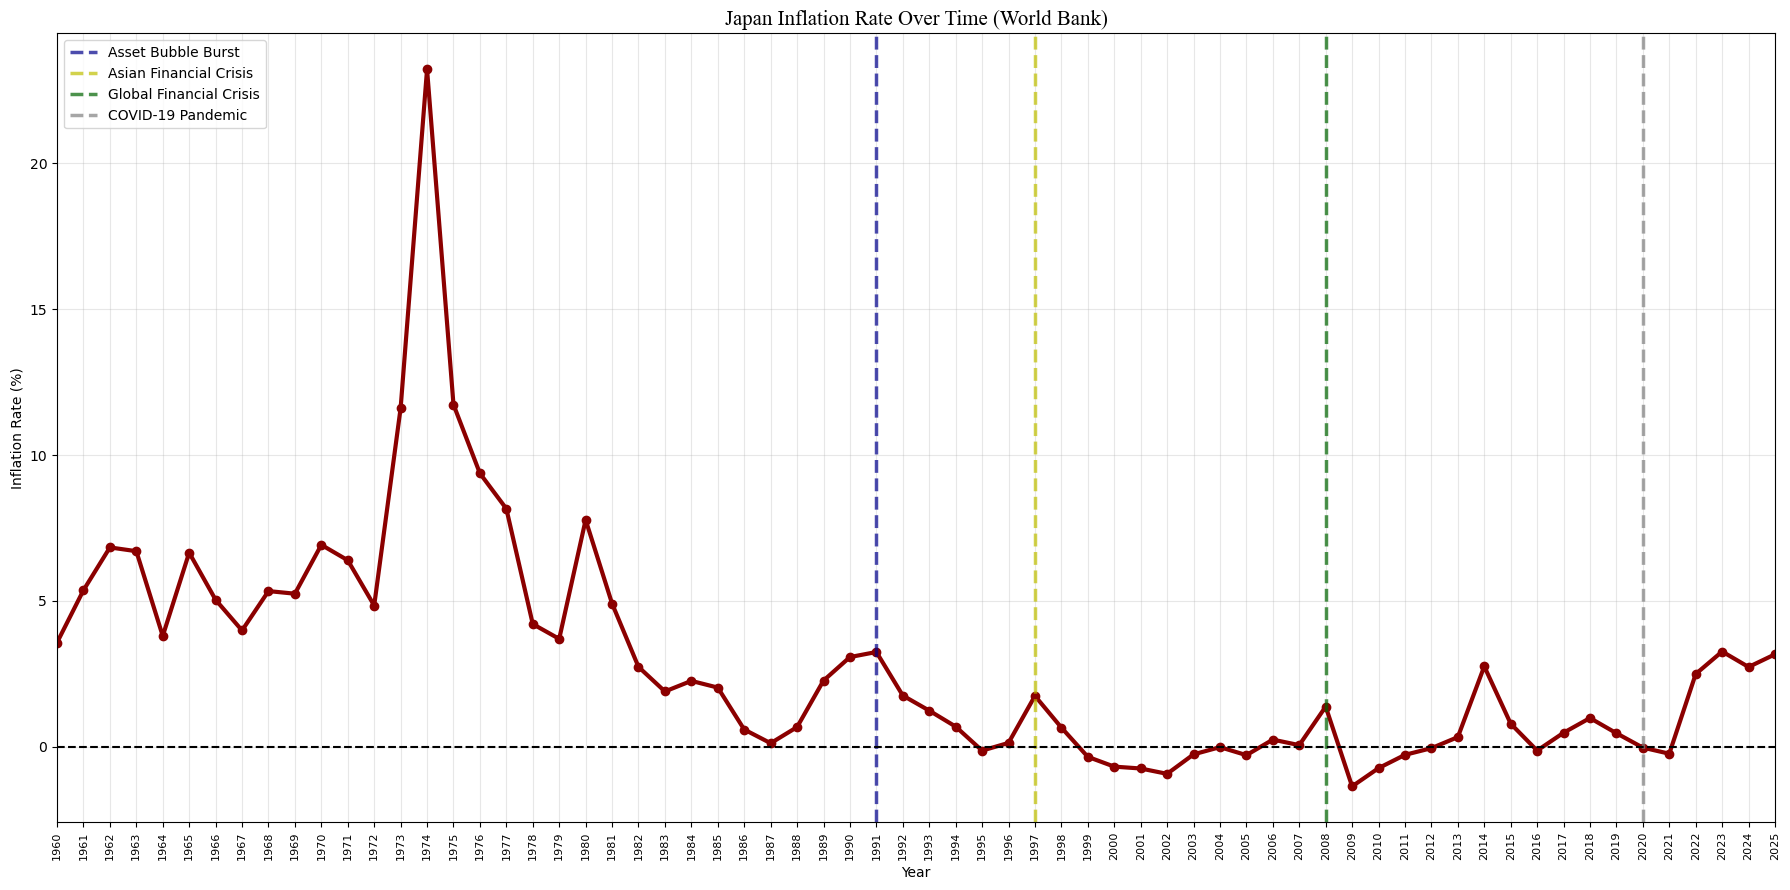

In [315]:
# ==================================================
# LOAD DATA
# ==================================================

df = pd.read_csv(
    r'C:\Users\reyf0\Dropbox\Work_Classification\01-Open_Projects\Writing_Sample\Data\Raw_data\InflationRate.csv',
    skiprows=4
)

# Japan row
japan = df[df['Country Name'].str.strip() == 'Japan'].iloc[0]

# Extract years
year_cols = [col for col in df.columns if col.isdigit()]

years = pd.to_numeric(year_cols)
inflation = pd.to_numeric(
    japan[year_cols].values,
    errors='coerce'
)

data = pd.DataFrame({
    'Year': years,
    'Inflation': inflation
}).dropna()

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(18, 9))

plt.plot(
    data['Year'],
    data['Inflation'],
    color='darkred',
    marker='o',
    lw=3
)

# Annual year ticks
plt.xticks(
    range(
        int(data['Year'].min()),
        int(data['Year'].max()) + 1,
        1
    ),
    rotation=90,
    fontsize=8
)

# Major Japanese economic inflection points
plt.axvline(1991, linestyle='--', alpha=0.7, lw=2.5, color='Darkblue', label='Asset Bubble Burst')
plt.axvline(1997, linestyle='--', alpha=0.7, lw=2.5, color='y', label='Asian Financial Crisis')
plt.axvline(2008, linestyle='--', alpha=0.7, lw=2.5, color='Darkgreen', label='Global Financial Crisis')
plt.axvline(2020, linestyle='--', alpha=0.7, lw=2.5, color='gray', label='COVID-19 Pandemic')
# Zero inflation line
plt.axhline(0, color='black', linestyle='--')

plt.title(
    'Japan Inflation Rate Over Time (World Bank)',
    fontname='Times New Roman',
    fontsize=15
)

plt.xlabel('Year')
plt.ylabel('Inflation Rate (%)')

plt.xlim(
    left=int(data['Year'].min()),
    right=int(data['Year'].max())
)

plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()


plt.savefig(r'C:\Users\reyf0\Dropbox\Work_Classification\01-Open_Projects\Writing_Sample\Data\Charts\Inflation_Rate.png',
     dpi=600,
     bbox_inches='tight'
 )

plt.show()

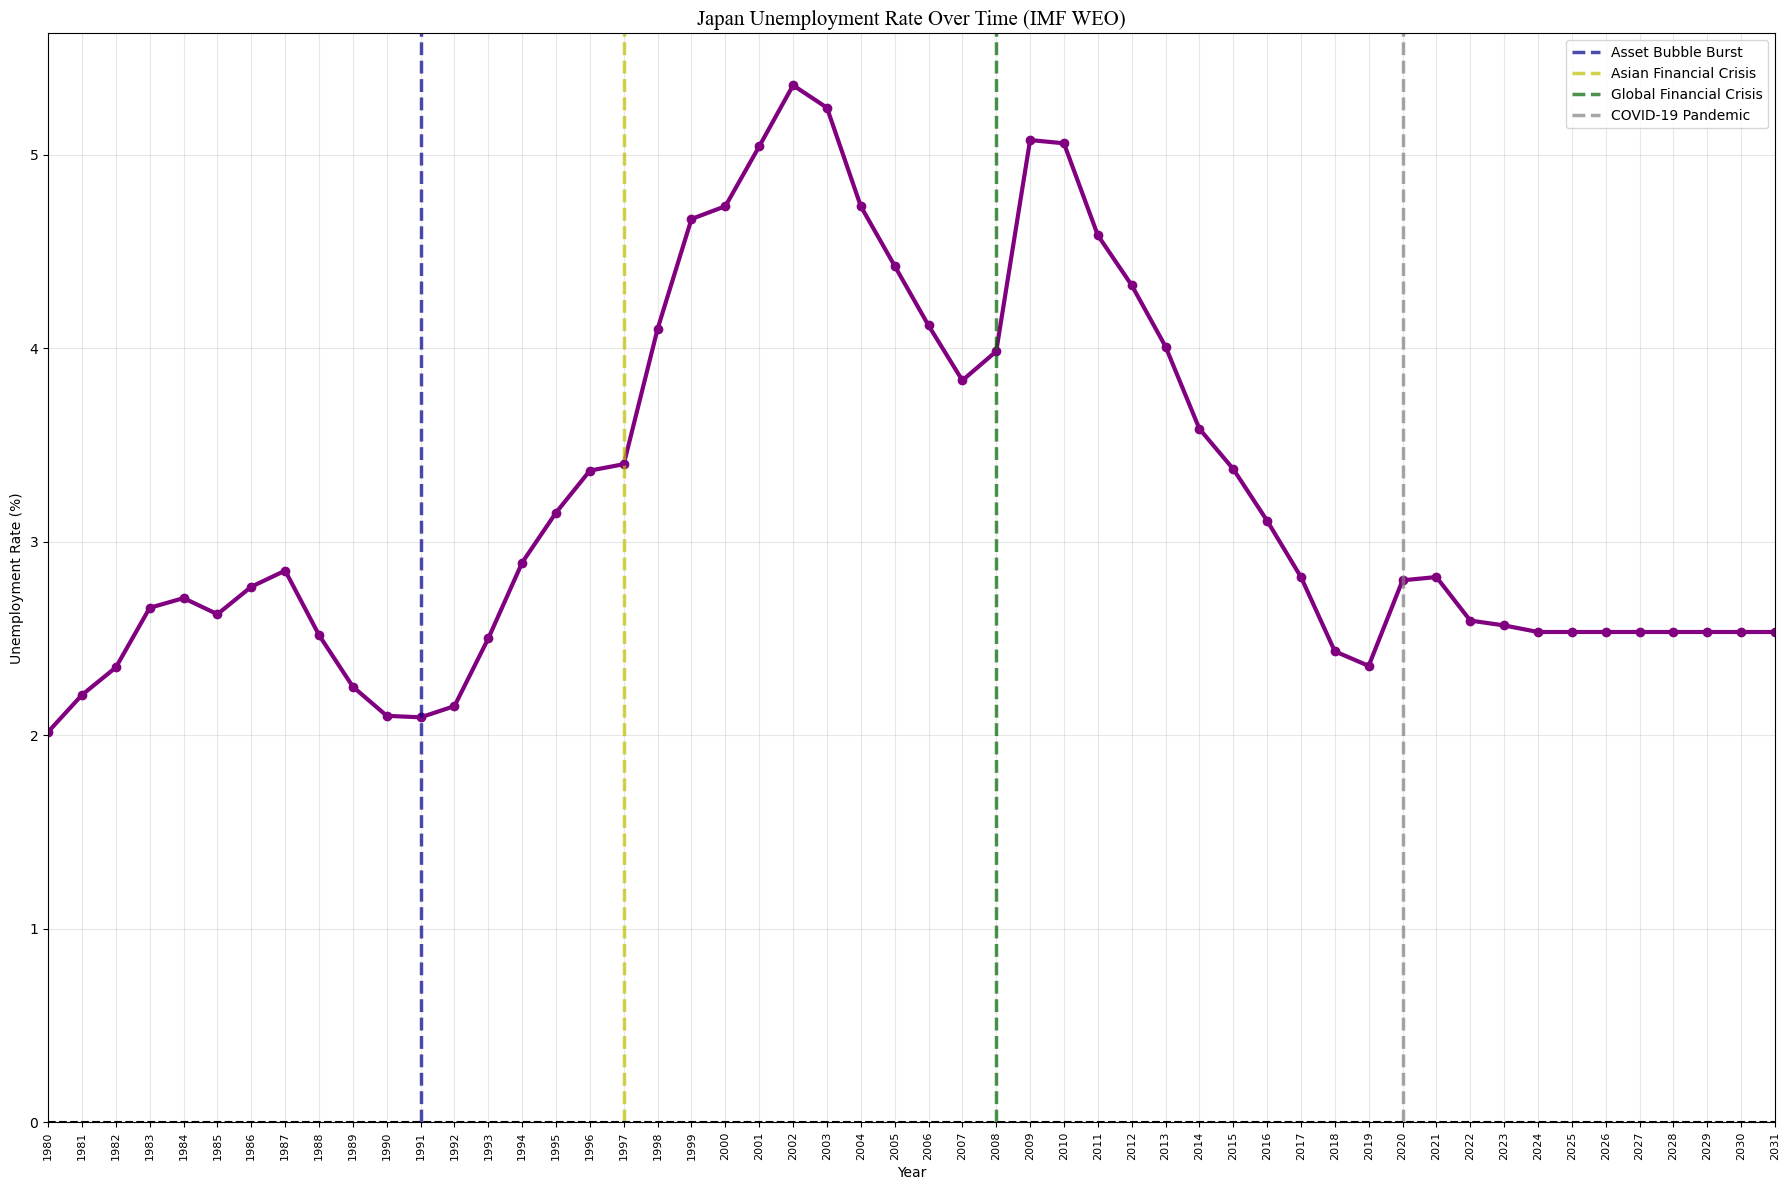

In [279]:
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# LOAD DATA
# ==================================================

df = pd.read_csv(
    r'C:\Users\reyf0\Dropbox\Work_Classification\01-Open_Projects\Writing_Sample\Data\Raw_data\IMF-Unemployment-rate.csv'
)

# Japan row
japan = df[df['COUNTRY'].str.strip() == 'Japan'].iloc[0]

# Extract years (1980 to 2031 per IMF WEO dataset structure)
year_cols = [col for col in df.columns if col.isdigit()]

years = pd.to_numeric(year_cols)
unemployment = pd.to_numeric(
    japan[year_cols].values,
    errors='coerce'
)

data = pd.DataFrame({
    'Year': years,
    'Unemployment': unemployment
}).dropna()

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(18, 12))

plt.plot(
    data['Year'],
    data['Unemployment'],
    color='purple',
    marker='o',
    lw=3
)

# Annual year ticks
plt.xticks(
    range(
        int(data['Year'].min()),
        int(data['Year'].max()) + 1,
        1
    ),
    rotation=90,
    fontsize=8
)

# Major Japanese macroeconomic & labor market inflection points
plt.axvline(1991, linestyle='--', alpha=0.7, lw = 2.5, color='Darkblue', label='Asset Bubble Burst')
plt.axvline(1997, linestyle='--', alpha=0.7, lw = 2.5, color='y', label='Asian Financial Crisis')
plt.axvline(2008, linestyle='--', alpha=0.7, lw = 2.5, color='Darkgreen', label='Global Financial Crisis')
plt.axvline(2020, linestyle='--', alpha=0.7, lw = 2.5, color='gray', label='COVID-19 Pandemic')

# Zero line for structural baseline tracking
plt.axhline(0, color='black', linestyle='--')

plt.title(
    'Japan Unemployment Rate Over Time (IMF WEO)',
    fontname='Times New Roman',
    fontsize=15
)

plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')

plt.xlim(
    left=int(data['Year'].min()),
    right=int(data['Year'].max())
)
plt.ylim(bottom = 0)

plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()

# Uncomment if desired
# plt.savefig(
#     r'C:\Users\reyf0\Dropbox\Work\_Classification\01-Open\_Projects\Writing\_Sample\Data\Charts\Unemployment\_Rate.png',
#     dpi=600,
#     bbox_inches='tight'
# )

plt.show()

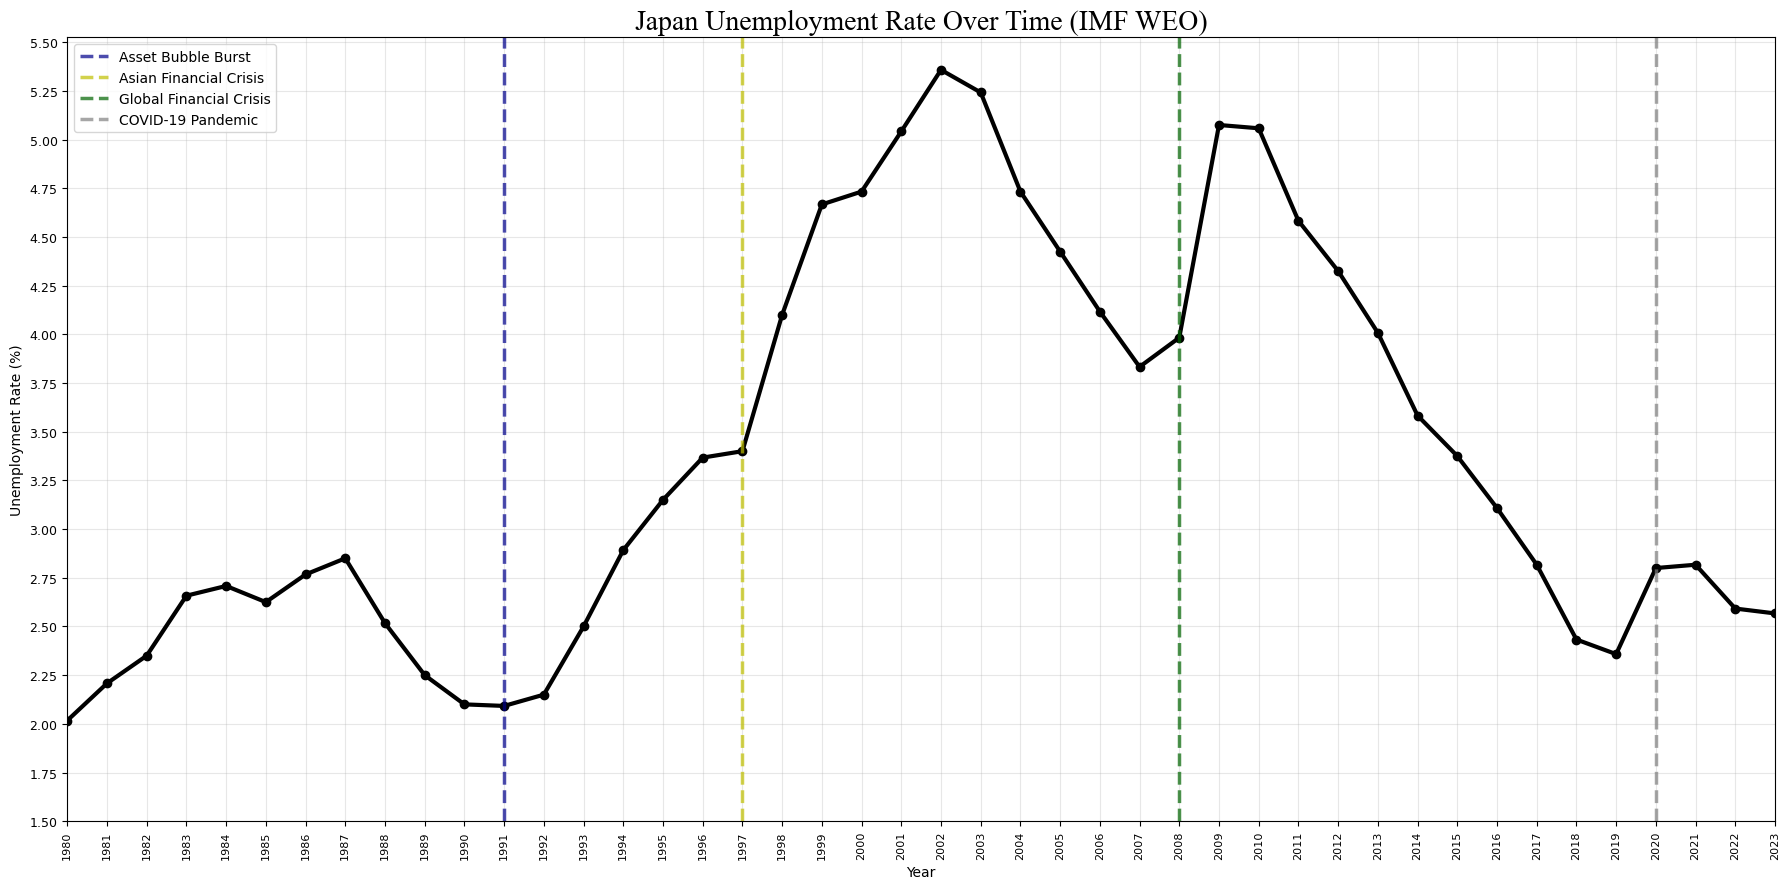

In [301]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# LOAD DATA
# ==================================================

df = pd.read_csv(
    r'C:\Users\reyf0\Dropbox\Work_Classification\01-Open_Projects\Writing_Sample\Data\Raw_data\IMF-Unemployment-rate.csv'
)

# Japan row
japan = df[df['COUNTRY'].str.strip() == 'Japan'].iloc[0]

# Extract years (1980 to 2031 per IMF WEO dataset structure)
year_cols = [col for col in df.columns if col.isdigit()]

years = pd.to_numeric(year_cols)
unemployment = pd.to_numeric(
    japan[year_cols].values,
    errors='coerce'
)

data = pd.DataFrame({
    'Year': years,
    'Unemployment': unemployment
}).dropna()

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(18, 9))

plt.plot(
    data['Year'],
    data['Unemployment'],
    color='k',
    marker='o',
    lw=3
)

# Annual year ticks
plt.xticks(
    range(
        int(data['Year'].min()),
        int(data['Year'].max()) + 1,
        1
    ),
    rotation=90,
    fontsize=8
)

# Y-axis ticks (set to increments of 0.25% for high density and visibility)
plt.yticks(
    np.arange(0, data['Unemployment'].max() + 0.25, 0.25),
    fontsize=9
)

# Major Japanese macroeconomic & labor market inflection points
plt.axvline(1991, linestyle='--', alpha=0.7, lw = 2.5, color='Darkblue', label='Asset Bubble Burst')
plt.axvline(1997, linestyle='--', alpha=0.7, lw = 2.5, color='y', label='Asian Financial Crisis')
plt.axvline(2008, linestyle='--', alpha=0.7, lw = 2.5, color='Darkgreen', label='Global Financial Crisis')
plt.axvline(2020, linestyle='--', alpha=0.7, lw = 2.5, color='gray', label='COVID-19 Pandemic')

# Zero line for structural baseline tracking
plt.axhline(0, color='black', linestyle='--')

plt.title(
    'Japan Unemployment Rate Over Time (IMF WEO)',
    fontname='Times New Roman',
    fontsize=20
)

plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')

plt.xlim(
    left=int(data['Year'].min()),
    right=int(data['Year'].max()-8)
)
plt.ylim(bottom = 1.5)

plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()

# Uncomment if desired
plt.savefig(
         r'C:\Users\reyf0\Dropbox\Work_Classification\01-Open_Projects\Writing_Sample\Data\Charts\IMF-Unemployment-rate.png',
     dpi=600,
     bbox_inches='tight'
)

plt.show()


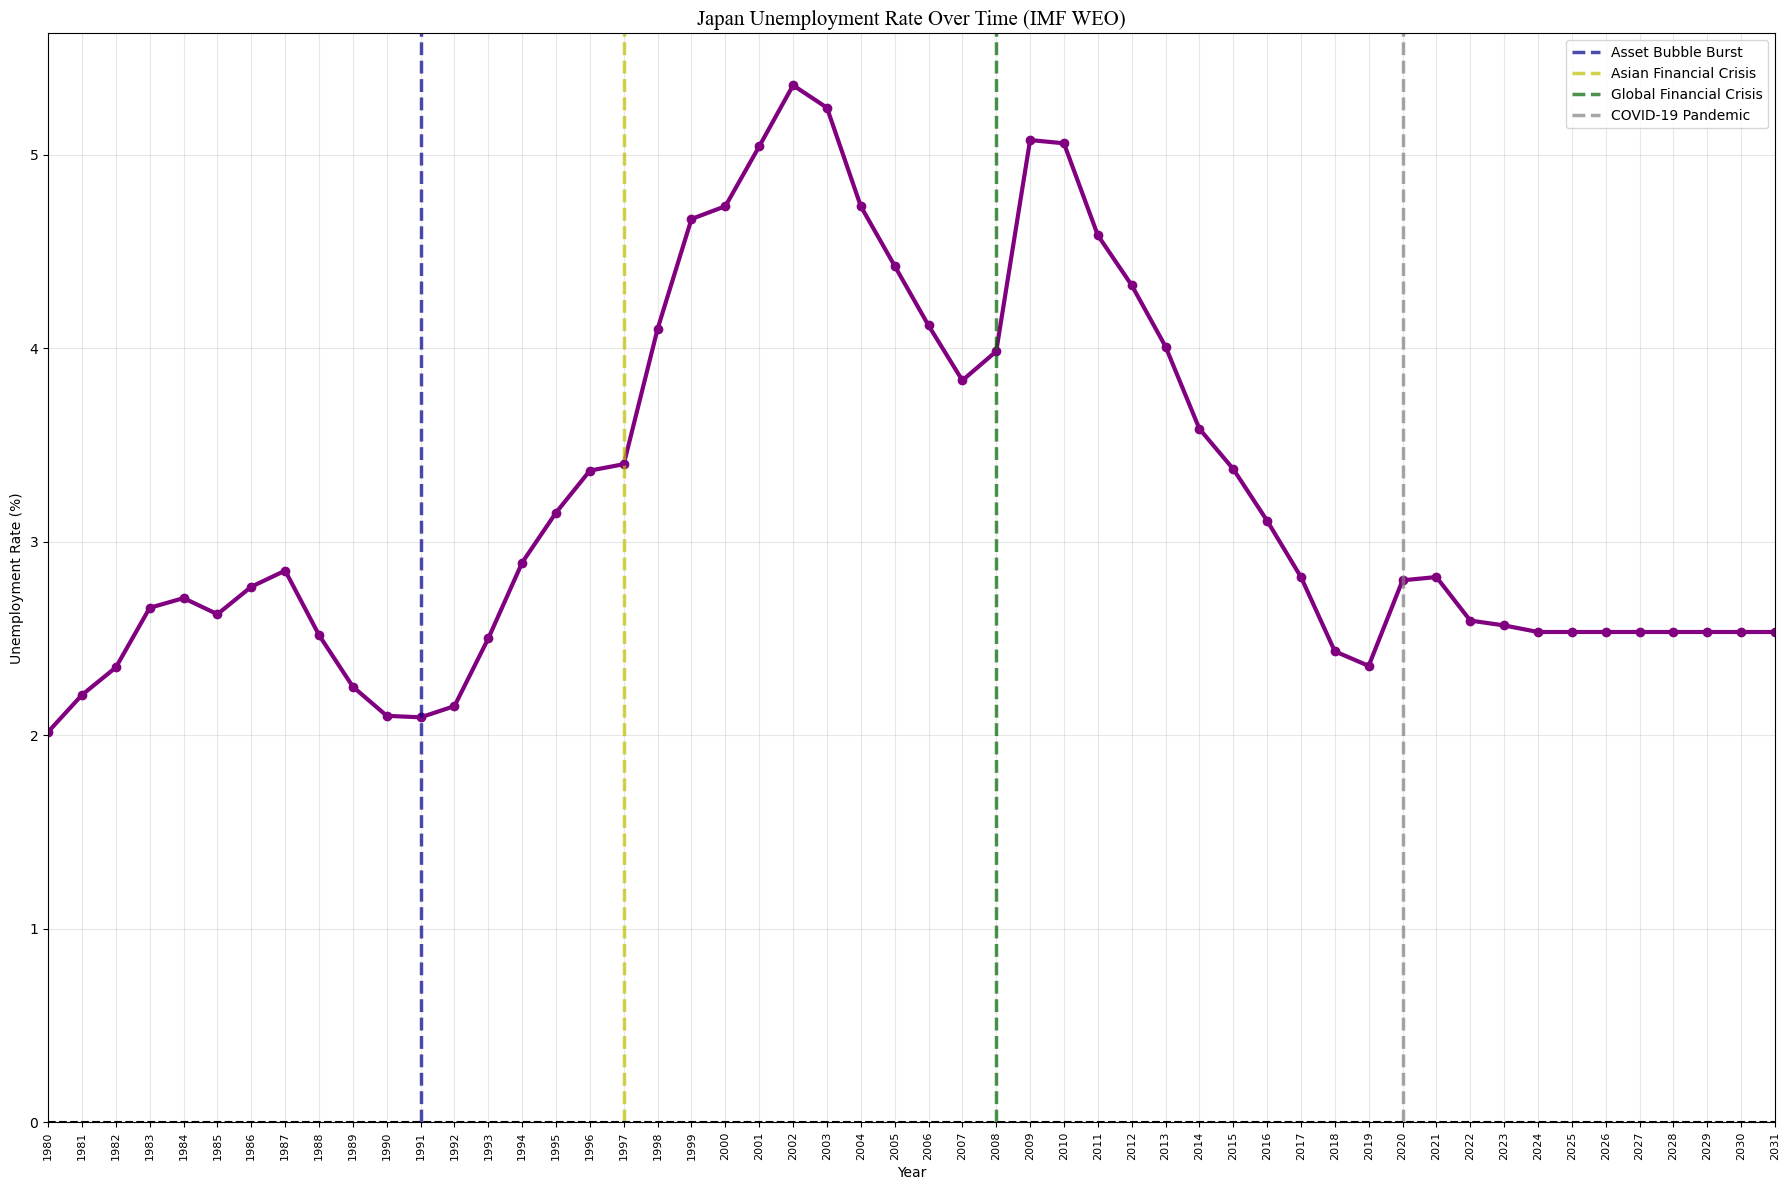

In [279]:
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# LOAD DATA
# ==================================================

df = pd.read_csv(
    r'C:\Users\reyf0\Dropbox\Work_Classification\01-Open_Projects\Writing_Sample\Data\Raw_data\IMF-Unemployment-rate.csv'
)

# Japan row
japan = df[df['COUNTRY'].str.strip() == 'Japan'].iloc[0]

# Extract years (1980 to 2031 per IMF WEO dataset structure)
year_cols = [col for col in df.columns if col.isdigit()]

years = pd.to_numeric(year_cols)
unemployment = pd.to_numeric(
    japan[year_cols].values,
    errors='coerce'
)

data = pd.DataFrame({
    'Year': years,
    'Unemployment': unemployment
}).dropna()

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(18, 12))

plt.plot(
    data['Year'],
    data['Unemployment'],
    color='purple',
    marker='o',
    lw=3
)

# Annual year ticks
plt.xticks(
    range(
        int(data['Year'].min()),
        int(data['Year'].max()) + 1,
        1
    ),
    rotation=90,
    fontsize=8
)

# Major Japanese macroeconomic & labor market inflection points
plt.axvline(1991, linestyle='--', alpha=0.7, lw=2.5, color='Darkblue', label='Asset Bubble Burst')
plt.axvline(1997, linestyle='--', alpha=0.7, lw=2.5, color='y', label='Asian Financial Crisis')
plt.axvline(2008, linestyle='--', alpha=0.7, lw=2.5, color='Darkgreen', label='Global Financial Crisis')
plt.axvline(2020, linestyle='--', alpha=0.7, lw=2.5, color='gray', label='COVID-19 Pandemic')

# Zero line for structural baseline tracking
plt.axhline(0, color='black', linestyle='--')

plt.title(
    'Japan Unemployment Rate Over Time (IMF WEO)',
    fontname='Times New Roman',
    fontsize=15
)

plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')

plt.xlim(
    left=int(data['Year'].min()),
    right=int(data['Year'].max())
)
plt.ylim(bottom = 0)

plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()

# Uncomment if desired
# plt.savefig(
#     r'C:\Users\reyf0\Dropbox\Work\_Classification\01-Open\_Projects\Writing\_Sample\Data\Charts\Unemployment\_Rate.png',
#     dpi=600,
#     bbox_inches='tight'
# )

plt.show()

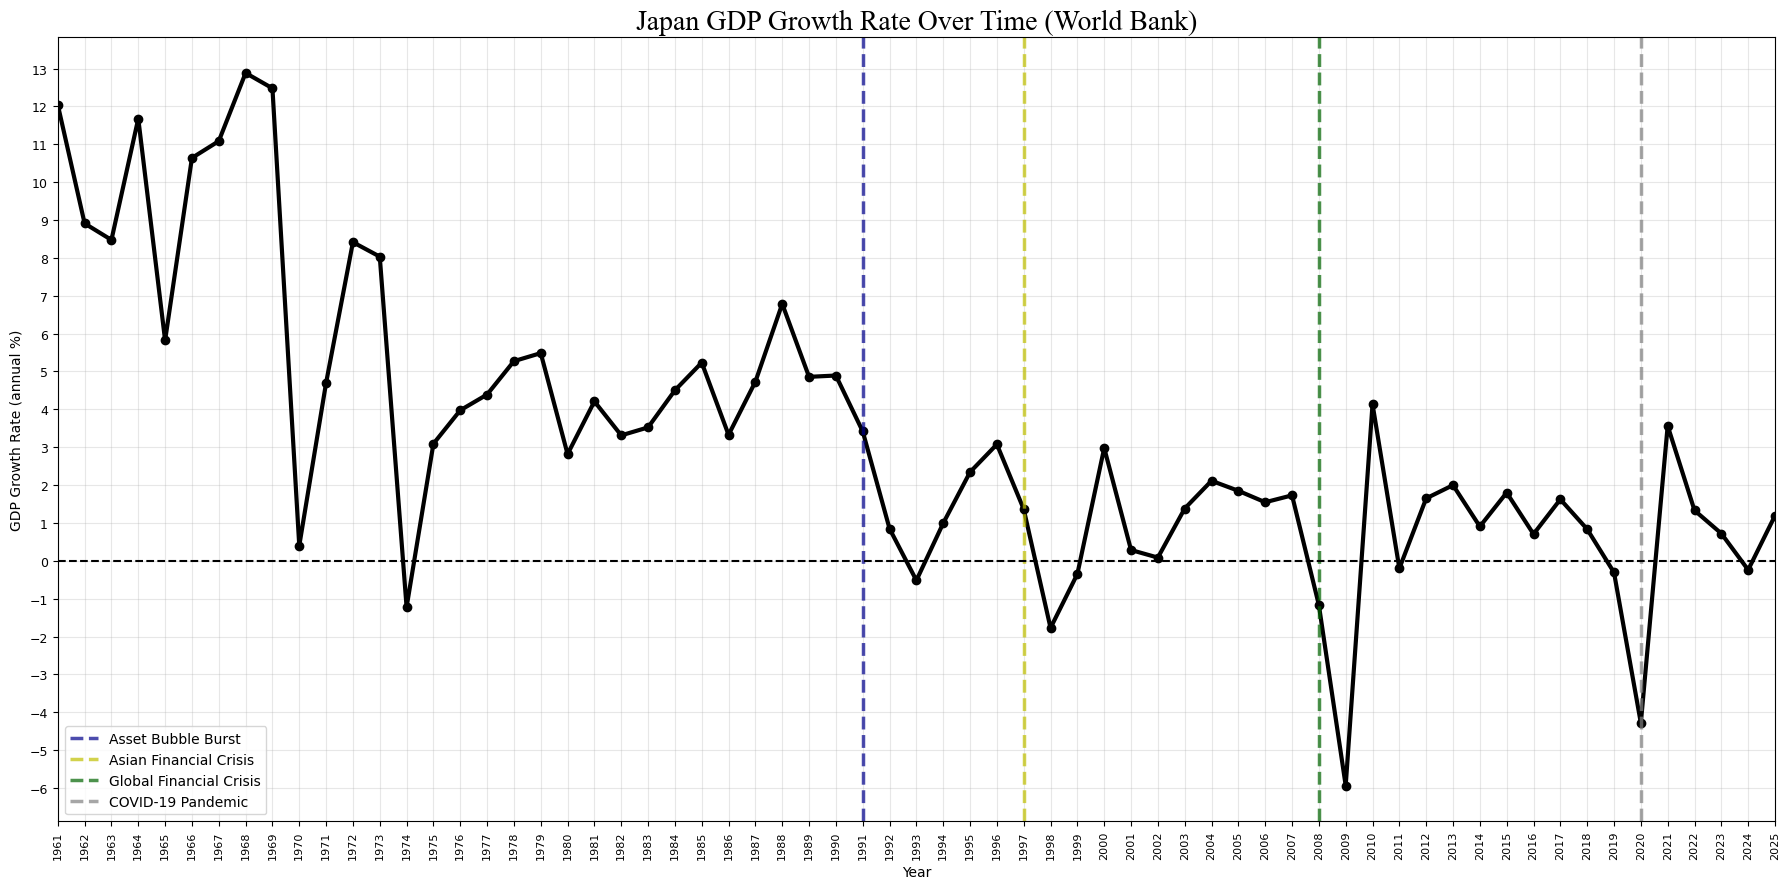

In [303]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==================================================
# LOAD DATA
# ==================================================

df = pd.read_csv(
    r'C:\Users\reyf0\Dropbox\Work_Classification\01-Open_Projects\Writing_Sample\Data\Raw_data\GDP_Growth.csv',
    skiprows=4
)

# Japan row
japan = df[df['Country Name'].str.strip() == 'Japan'].iloc[0]

# Extract years (1960 to 2025 per World Bank dataset structure)
year_cols = [col for col in df.columns if col.isdigit()]

years = pd.to_numeric(year_cols)
gdp_growth = pd.to_numeric(
    japan[year_cols].values,
    errors='coerce'
)

data = pd.DataFrame({
    'Year': years,
    'GDP_Growth': gdp_growth
}).dropna()

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(18, 9))

plt.plot(
    data['Year'],
    data['GDP_Growth'],
    color='k',
    marker='o',
    lw=3
)

# Annual year ticks
plt.xticks(
    range(
        int(data['Year'].min()),
        int(data['Year'].max()) + 1,
        1
    ),
    rotation=90,
    fontsize=8
)

# Y-axis ticks (Dense identifiers set to increments of 1.0% for high visibility)
y_min = np.floor(data['GDP_Growth'].min())
y_max = np.ceil(data['GDP_Growth'].max())
plt.yticks(
    np.arange(y_min, y_max + 1.0, 1.0),
    fontsize=9
)

# Major Japanese macroeconomic & labor market inflection points
plt.axvline(1991, linestyle='--', alpha=0.7, lw=2.5, color='Darkblue', label='Asset Bubble Burst')
plt.axvline(1997, linestyle='--', alpha=0.7, lw=2.5, color='y', label='Asian Financial Crisis')
plt.axvline(2008, linestyle='--', alpha=0.7, lw=2.5, color='Darkgreen', label='Global Financial Crisis')
plt.axvline(2020, linestyle='--', alpha=0.7, lw=2.5, color='gray', label='COVID-19 Pandemic')

# Zero line for structural baseline tracking
plt.axhline(0, color='black', linestyle='--')

plt.title(
    'Japan GDP Growth Rate Over Time (World Bank)',
    fontname='Times New Roman',
    fontsize=20
)

plt.xlabel('Year')
plt.ylabel('GDP Growth Rate (annual %)')

plt.xlim(
    left=int(data['Year'].min()),
    right=int(data['Year'].max())
)

plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()

# Uncomment if desired
plt.savefig(
     r'C:\Users\reyf0\Dropbox\Work_Classification\01-Open_Projects\Writing_Sample\Data\Charts\GDP_Growth.png',
     dpi=600,
     bbox_inches='tight'
)

plt.show()